In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers, models

In [2]:
data_train_path = 'Fruits_Vegetables/train'
data_test_path = 'Fruits_Vegetables/test'
data_val_path = 'Fruits_Vegetables/validation'

In [3]:
img_width = 180
img_height = 180

In [4]:
data_train = tf.keras.utils.image_dataset_from_directory(
    data_train_path,
    shuffle=True,
    image_size=(img_width, img_height),
    batch_size=32,
    validation_split=False
)

Found 3115 files belonging to 36 classes.


In [5]:
data_cat = data_train.class_names

In [6]:
data_val = tf.keras.utils.image_dataset_from_directory(
    data_val_path,
    shuffle=True,
    image_size=(img_width, img_height),
    batch_size=32,
    validation_split=False
)

Found 351 files belonging to 36 classes.


In [7]:
data_text = tf.keras.utils.image_dataset_from_directory(
    data_test_path,
    shuffle=True,
    image_size=(img_width, img_height),
    batch_size=32,
    validation_split=False
)

Found 359 files belonging to 36 classes.


In [8]:
data_cat = data_train.class_names

In [9]:
data_cat

['apple',
 'banana',
 'beetroot',
 'bell pepper',
 'cabbage',
 'capsicum',
 'carrot',
 'cauliflower',
 'chilli pepper',
 'corn',
 'cucumber',
 'eggplant',
 'garlic',
 'ginger',
 'grapes',
 'jalepeno',
 'kiwi',
 'lemon',
 'lettuce',
 'mango',
 'onion',
 'orange',
 'paprika',
 'pear',
 'peas',
 'pineapple',
 'pomegranate',
 'potato',
 'raddish',
 'soy beans',
 'spinach',
 'sweetcorn',
 'sweetpotato',
 'tomato',
 'turnip',
 'watermelon']

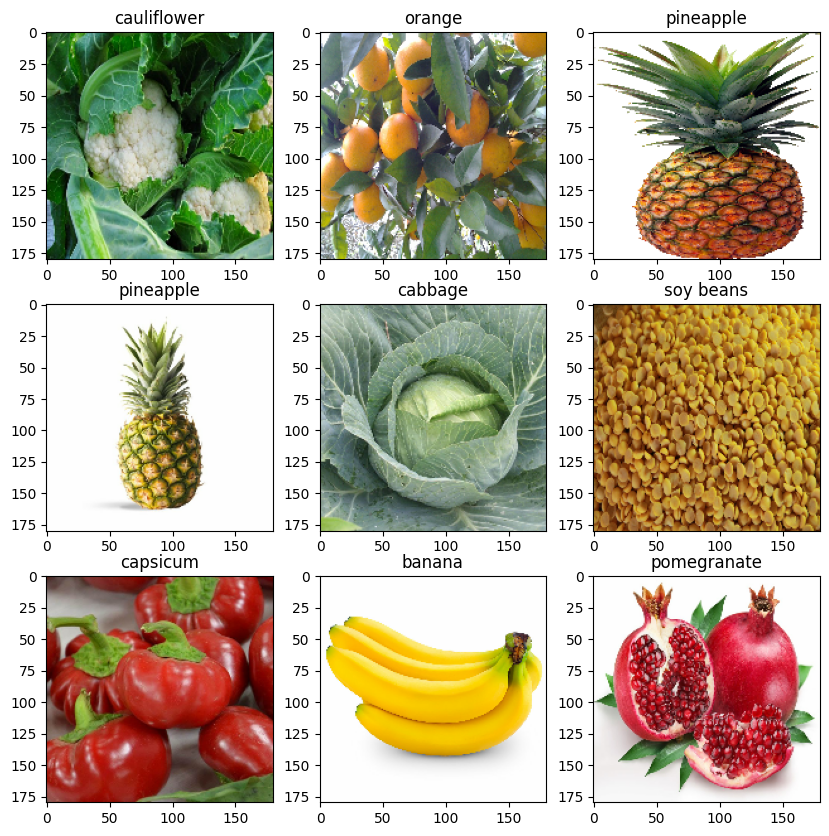

In [10]:
plt.figure(figsize=(10, 10))
for image, label in data_train.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(image[i].numpy().astype("uint8"))
        plt.title(data_cat[label[i]])
        plt.axis()

In [11]:
from tensorflow.keras.models import Sequential

In [12]:
data_train

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [13]:
model = Sequential([
    layers.Rescaling(1./255),
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dropout(0.2),
    layers.Dense(128),
    layers.Dense(len(data_cat))
    
    
])    

In [14]:
model.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])

In [16]:
epochs_size = 25
history = model.fit(data_train, validation_data=data_val, epochs=epochs_size)

Epoch 1/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 60s 601ms/step - accuracy: 0.0554 - loss: 3.7116 - val_accuracy: 0.3248 - val_loss: 2.4234
Epoch 2/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 15s 156ms/step - accuracy: 0.2728 - loss: 2.5379 - val_accuracy: 0.5840 - val_loss: 1.5265
Epoch 3/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 15s 150ms/step - accuracy: 0.4112 - loss: 2.0379 - val_accuracy: 0.7094 - val_loss: 1.1796
Epoch 4/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 15s 151ms/step - accuracy: 0.5468 - loss: 1.5714 - val_accuracy: 0.8262 - val_loss: 0.7438
Epoch 5/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 16s 157ms/step - accuracy: 0.7108 - loss: 1.0530 - val_accuracy: 0.8547 - val_loss: 0.5780
Epoch 6/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 17s 163ms/step - accuracy: 0.8140 - loss: 0.6739 - val_accuracy: 0.9259 - val_loss: 0.3993
Epoch 7/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 16s 156ms/step - accuracy: 0.8812 - loss: 0.3820 - val_accuracy: 0.9316 - val_loss: 0.3470
Epoch 8/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 16s 161ms/step - accuracy: 0.9213 - loss: 0.2679 - val_accu

Text(0.5, 1.0, 'Loss')

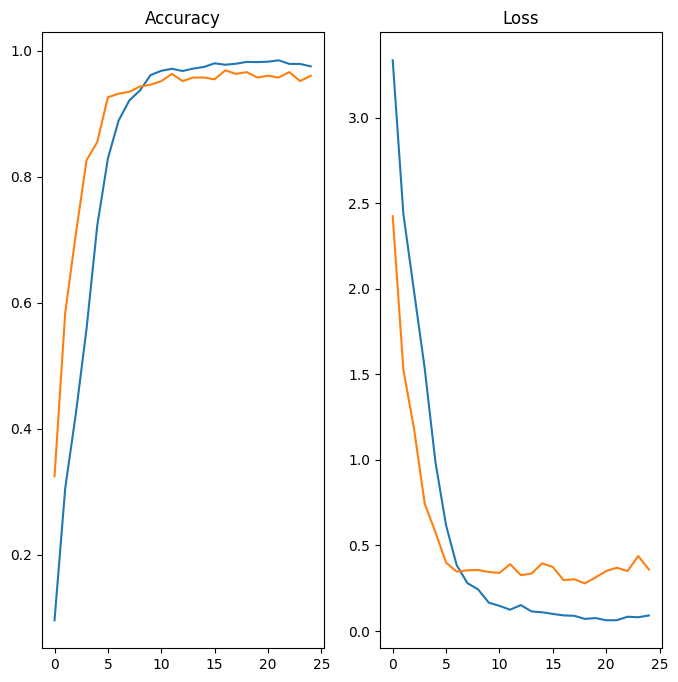

In [19]:
epochs_range = range(epochs_size)
plt.figure(figsize=(8, 8))
plt.subplot(1,2,1)
plt.plot(epochs_range,history.history['accuracy'], label = 'Training Accuracy')
plt.plot(epochs_range, history.history['val_accuracy'], label = 'Validation Loss')
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range,history.history['loss'], label = 'Training Loss')
plt.plot(epochs_range, history.history['val_loss'], label = 'Validation Loss')
plt.title('Loss')

In [20]:
image = 'Chilli.jpg'
image = tf.keras.utils.load_img(image, target_size=(img_height, img_width))
img_array = tf.keras.utils.img_to_array(image)
img_bat = tf.expand_dims(img_array, 0)

In [21]:
predict = model.predict(img_bat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


In [22]:
score = tf.nn.softmax(predict)

In [23]:
print('Veg/Fruit in image is {} with accuracy of {:0.2f}'.format(data_cat[np.argmax(score)], np.max(score)*100))

Veg/Fruit in image is chilli pepper with accuracy of 99.95
